In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
#--- DIRECTORIES-----
BASE_DIR = '/content/drive/MyDrive/xn-sitstayforever'
DATASET_DIR = f'{BASE_DIR}/datasets'
OUTPUTS_DIR = f'{BASE_DIR}/outputs'
CHECKPOINTS_DIR = f'{BASE_DIR}/checkpoints'
IMAGE_DIR = f'{DATASET_DIR}/product_images'

print(DATASET_DIR)

/content/drive/MyDrive/xn-sitstayforever/datasets


# Setup & Imports

In [6]:
# Installs for missing dependencies not natively supported
!pip install open-clip-torch -q

print("Open CLIP install successful!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
Open CLIP install successful!


In [7]:
#------- IMPORTS -------------
# --System Libraries---
import os
import sys
import random
from pathlib import Path

# --Data Handling---
import numpy as np
import pandas as pd
import requests

# --Visualizations---
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# --Preprocessing & Encoding---
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans



# --Image Processing---
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
from tqdm import tqdm # wraps any loop and gives a live progress bar when loading the images in a loop

# --Deep Learning---
import torch
import torchvision.transforms as transforms

# --CLIP---
import open_clip

print("All Libraries have been successfully imported!")

All Libraries have been successfully imported!


# Dataset Loading

In [8]:
'''Smoke Test for verfiying directories, paths, and datasets are loading properly'''
import os

# File path smoke test, since files are in a google drive and mounted
# for item in os.listdir(BASE_DIR):
#   print(repr(item))
print('=' * 50)
for item in os.listdir(DATASET_DIR):
  print(item)
print('=' * 50)
# check exact folder name including hidden characters
items = os.listdir(BASE_DIR)
for item in items:
  print(repr(item))

# check it path exists
print(os.path.exists(DATASET_DIR))

SSF_CV_Dataset.xlsx
pet_cv_dataset_full.xlsx
product_images
'datasets'
'checkpoints'
'outputs'
True


In [9]:
# ------ LOADING THE DATASET ------
''' The dataset consists of 54 images,
text, 2 spreadsheets which need to
be imported, analyzed and clean during
this preprocessing stage'''

# load the pet_cv_dataset.xlsx using pandas
df_images = pd.read_excel(f'{DATASET_DIR}/pet_cv_dataset_full.xlsx', sheet_name='images_cv_features')
df_products = pd.read_excel(f'{DATASET_DIR}/pet_cv_dataset_full.xlsx', sheet_name='product_summary')

# load SSF_CV_Dataset.xlsx using pandas
df_ssf = pd.read_excel(f'{DATASET_DIR}/SSF_CV_Dataset.xlsx', sheet_name='images_cv_features')
df_keywords = pd.read_excel(f'{DATASET_DIR}/SSF_CV_Dataset.xlsx', sheet_name='keywords_dataset')

# --Outputs---#
print(f'(df_images:   {df_images.shape}')
print(f'(df_products:   {df_products.shape}')
print(f'(df_ssf:   {df_ssf.shape}')
print(f'(df_keywords:   {df_keywords.shape}')

print('=' * 50)
''' Note:
df_images is outputting 145,44 instead of 54,44 to follow the 54 images. Its reading all 100 metadata rows plus the
54 rows combined. Will resolve this next section'''

(df_images:   (145, 44)
(df_products:   (100, 12)
(df_ssf:   (6, 36)
(df_keywords:   (146, 12)


' Note:\ndf_images is outputting 145,44 instead of 54,44 to follow the 54 images. Its reading all 100 metadata rows plus the\n54 rows combined. Will resolve this next section'

In [10]:
# ------ LOADING THE IMAGES FROM GOOGLE DRIVE ------
''' This section will handle loading the images from the dataset. The images are stored in a folder on
Google drive

- since the imags can come in different channel formats, RGBA, grayscale, palette-based, it would be best to unify the formats
  - this will help our other models like CLIP, GradCAM etc to interpret the the same format instead of mixed formats



Storing the images and filepaths seperately for useablilty for other libaries and models. Better for memory and speed
'''

images = {} # store image objects in empty dictionary, ordered by filename
image_paths = {} # store full image file paths by filename to ensure we have correct location

# check file name, path, extension and sort
'''tqdm adds a real-time progress bar to the loop to track execution speed
    and time for image uploads to the dictionaries '''
for filename in tqdm(sorted(os.listdir(IMAGE_DIR))):
  if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
    filepath = os.path.join(IMAGE_DIR, filename)

    try:
      img = Image.open(filepath).convert('RGB') # read the image from drive and convert pixels to RGB (to standardize color 3 color channels)
      images[filename] = img
      image_paths[filename] = filepath
    except Exception as e:
      print(f"Error loading image {filename}: {e}")
      continue

print(f'\nLoaded {len(images)} images from {IMAGE_DIR}')


100%|██████████| 63/63 [00:19<00:00,  3.30it/s]


Loaded 63 images from /content/drive/MyDrive/xn-sitstayforever/datasets/product_images


In [11]:
''' Issue 1: After filtering the rows, seems as if too many rows were removed. Specially the ones that are tier 'low'
Validating what happened

 '''

print("Before filtering:")
for tier, count in df_images['performance_tier'].value_counts().items():
    print(f"  {tier}: {count}")

print("Does low tier rows have brightness_mean values? :")
low_tier_rows = df_images[df_images['performance_tier'] == 'low']
if low_tier_rows['brightness_mean'].notna().any():
    count_with_brightness = low_tier_rows['brightness_mean'].notna().sum()
    print(f"  Yes, {count_with_brightness} rows have brightness_mean values.")
else:
    count_without_brightness = low_tier_rows['brightness_mean'].isna().sum()
    print(f"  No, {count_without_brightness} rows do not have brightness_mean values.")

Before filtering:
  high: 75
  medium: 33
  low: 31
  sponsor: 6
Does low tier rows have brightness_mean values? :
  No, 31 rows do not have brightness_mean values.


In [12]:
# ---- Data Quality -----------------------

''' this section will be used to filter and clean the features and metadata

After troubleshooting and looking through the dataset spreadsheet again, found that the tier breakdown had missing images
and for those images brightness_mean' was NaN

Of the 145 rows in pet_cv_dataset_full
- 54 rows have computed CV features, where brightness_mean is not null = working images
- 91 rows are metadata-only = no downloaded images (Burts Bees and Bio Groom images)

Of the 54 usable image rows:
- high: 42 images (7 ASINs × 6 images)
- medium: 6 images (1 ASIN × 6 images)
- sponsor: 6 images (1 ASIN × 6 images — Sit Stay Forever)
- low: 0 images — no low tier products were downloaded


Conclusion/Impact:
With no low tier images, downstream model training will need to be adjusted.

treating it like a binary task (high v. medium/low)
OR
2-class problem (high v. sponsor benchmark)

will revisit in Notebook 2
'''

# filter to rows with computed CV features only (drop meta-data rows)
df_clean = df_images[df_images['brightness_mean'].notna()].copy()


# From starter template in xlsx. Convert CV Feature columns to numeric
CV_FEATURES = [
    'brightness_mean', 'contrast_std', 'sharpness_laplacian',
    'white_bg_pct', 'white_bg_compliance', 'product_dominance_score',
    'text_density_pct', 'clutter_score', 'color_warmth', 'saturation_mean',
    'symmetry_score', 'dominant_color_1_pct', 'ocr_word_count', 'ocr_keyword_count'

]


# create a new column for cleaned data and convert values of column to numeric data types
df_clean[CV_FEATURES] = df_clean[CV_FEATURES].apply(pd.to_numeric, errors='coerce') # turn any non-numeric string or invalid values to NaN

print(f'Total # of rows before filtering: {df_images.shape[0]}')
print(f'Total # of rows after filtering: {df_clean.shape[0]}')

# counting the number of values in the performance tier column then storing the label and count in a dictionary
print("~" * 50)
print("Total Tiers present:")
for tier, count in df_clean['performance_tier'].value_counts().items():
    print(f"  {tier}: {count}")

Total # of rows before filtering: 145
Total # of rows after filtering: 54
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total Tiers present:
  high: 42
  sponsor: 6
  medium: 6


In [13]:
# ---- Flagging problematic images ------------------
''' checking if images descriptions align with image instead stating Amazon UI text.
some images that were datascrapped, i found some images with incorrect context'''

# creating new column to mark images theat are good to go
df_clean['quality_flag'] = 'ok'

# --- Detection 1: Amazon Banner Screenshots ---------------
# detext is Amazon product images contain any Amazon UI text
# checking OCR for any promotional/navigational langugage not related to the product
banner_terms = [
    'spend', 'meds', 'prime', 'shop amazon',
    'school', 'get back', 'introducing', 'restrictions apply'
]

# checking if text is in banner terms
def is_banner_txt(ocr_text):
  if pd.isna(ocr_text):
    return False
  ocr_lower = str(ocr_text).lower()
  for term in banner_terms:
    if term in ocr_lower:
      return True
  return False

# running text in ocr_text to see if it contains the banner terms
banner_mask = df_clean['ocr_text'].apply(is_banner_txt)
df_clean.loc[banner_mask, 'quality_flag'] = 'banner_screenshot'

# --- Output # of Banner Screenshots detected -----------
print(f'Total # of banner screenshots: {banner_mask.sum()}')
if banner_mask.sum() > 0:
  # looking through flagged rows for verification
  print(df_clean.loc[banner_mask, ['asin', 'brand', 'image_type_label', 'ocr_text']].to_string(index=False))

# ---



Total # of banner screenshots: 6
      asin       brand image_type_label                                                                                  ocr_text
B01K4SH5JW Burt's Bees     product_main Spend less on your meds Prime members save up to 80%* amazon pharmacy *Restrictions apply
B01K4SH5JW Burt's Bees        lifestyle                                      Get back to school ready Our Top 100+ go-to supplies
B01K4SH5JW Burt's Bees      infographic                                          Introducing The Run Shop Gear to match your pace
B01K4SH5JW Burt's Bees        secondary           Shop early deals Shop Amazon devices up to /0% off prime day Limited-time offer
B01K4SH5JW Burt's Bees        secondary                                                         prime original New series prime A
B01K4SH5JW Burt's Bees        secondary                             Prime Day is = June 23-26 Members unlock early deals aa ——— >


In [14]:
# ---- Flagging problematic images Continued... ------------------

# --- Detection 2: Low resolution images ----------------
''' Finding images below 400px. Upscaling these images to a consistent px could stretch the image and present more noise.
using the cleaned dataframe, checking columns width_px and height_px to see if they are below 400px

 '''
low_resolution_mask = (df_clean['width_px'] < 400) & (df_clean['height_px'] < 400)
df_clean.loc[low_resolution_mask, 'quality_flag'] = 'low_resolution'

# --- Output # of low res images detected -----------
print(f'Total # of low res images : {low_resolution_mask.sum()}')
if low_resolution_mask.sum() > 0:
  # looking through flagged rows for verification
  print(df_clean.loc[low_resolution_mask, ['asin', 'brand', 'width_px', 'height_px']].to_string(index=False))

Total # of low res images : 17
      asin        brand  width_px  height_px
B0002DIUVQ    Bio-Groom     230.0      230.0
B0002DIUVQ    Bio-Groom     115.0      115.0
B0002DIUVQ    Bio-Groom     345.0      345.0
B0002DIUVQ    Bio-Groom     230.0      230.0
B0002DIUVQ    Bio-Groom     115.0      115.0
B0002DIUVQ    Bio-Groom     345.0      345.0
B001GY0NPG Isle of Dogs     354.0      354.0
B001GY0NPG Isle of Dogs     354.0      354.0
B001GY0NPG Isle of Dogs     354.0      354.0
B001GY0NPG Isle of Dogs     354.0      354.0
B001GY0NPG Isle of Dogs     354.0      354.0
B001GY0NPG Isle of Dogs     354.0      354.0
B0002DINX6    Sulfodene     230.0      230.0
B0002DINX6    Sulfodene     115.0      115.0
B0002DINX6    Sulfodene     345.0      345.0
B0002DINX6    Sulfodene     230.0      230.0
B0002DINX6    Sulfodene     115.0      115.0


In [15]:
#--- Binary Tier Relabeling -------
'''
This cell will handle the relabeling of the tiers do to no 'low' tier images and the six SSF 'sponsor' tier getting
relabeled for training purposes.

Setting up 2 main tiers 'high' versus 'medium' as of now and will address the imbalance in Notebook 2


---------------------------------
CHANGE FROM PROFESSOR FEEDBACK:
- Previous SSF (sponsor tier) was relabeled to 'high' and included in df_clean for training. Completely eliminating low tiers since they ddnt have images.
Professor flagged this as data leakage and the model would learn 'looks like SSF = high performer" rather than actually using visual features to drive performance.

FIX:
- SSF images held out as dedicated Evaluaiton set
- Competitors images go into the Training set
- tier_original will be preserved, downstream cells can still identify SSF images by their original label
'''

# preserve the original performance_tier column by making a copy before any splitting
df_clean['tier_original'] = df_clean['performance_tier'].copy()

# Evaluation Set: Sit Stay Forever images only ( never user in training)
df_ssf_eval = df_clean[df_clean['performance_tier'] == 'sponsor'].copy()

# Training set: competitors only (high + medium)
df_train = df_clean[df_clean['performance_tier'].isin(['high', 'medium'])].copy()

def tier_counter():
  # count the number of items in each tier group
  for tier, count in df_train['performance_tier'].value_counts().items():
    print(f"            {tier}: {count}")

print('=' * 50)
print(f'EVALUTION SET (SSF sponsor - held out):')
print('=' * 50)
print(f'    Total / sponsors: {len(df_ssf_eval)}')
print('=' * 50)

print(f'TRAINING SET:')

print('=' * 50)
print(f'  Training Total: {len(df_train)}')
tier_counter() # Call the function without wrapping it in another print()
print('~' * 55)
print(f'Total Combined:   {len(df_train) + len(df_ssf_eval)}')


EVALUTION SET (SSF sponsor - held out):
    Total / sponsors: 6
TRAINING SET:
  Training Total: 48
            high: 42
            medium: 6
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total Combined:   54


In [16]:
#------ Data quality summary -----
print('Data Quality Summary')
print('=' * 55)

#total rows in raw datasets
print(f'Total Rows in raw dataset: {df_images.shape[0]}')

#total rows in cleaned dataset
print(f'Total Usable Rows after filtering the dataset: {df_clean.shape[0]}')

# number of metadata rows dropped
print(f'Metadata rows dropped: {df_images.shape[0] - df_clean.shape[0]}')

print('~' * 55)
print("Number of quality flags:")
for flag, count in df_clean['quality_flag'].value_counts().items():
  print(f'  {flag}: {count}')

print('~' * 55)
tier_counter() # Call the function without wrapping it in another print()

Data Quality Summary
Total Rows in raw dataset: 145
Total Usable Rows after filtering the dataset: 54
Metadata rows dropped: 91
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Number of quality flags:
  ok: 31
  low_resolution: 17
  banner_screenshot: 6
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            high: 42
            medium: 6


In [17]:
# ============================================================
# SECTION 4 — EXPLORATORY DATA ANALYSIS
# Compare SSF vs competitors on three headline visual features.
#
# Three stages:
#   Stage 1: naive comparison on ALL images (misleading result)
#   Stage 2: diagnostic — trace the distortion to low-res images
#   Stage 3: corrected comparison on CLEAN images only
# Input: df_clean (54 usable rows from the preprocessing step)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# --- Split by ORIGINAL tier (before the sponsor->high relabeling) ---
# tier_original: 'sponsor' = SSF's own products,
#                'high'/'medium' = competitors.
# Using tier_original (not performance_tier) keeps SSF separable.
ssf       = df_clean[df_clean['tier_original'] == 'sponsor'].copy()
high_comp = df_clean[df_clean['tier_original'] == 'high'].copy()
med_comp  = df_clean[df_clean['tier_original'] == 'medium'].copy()

HEADLINE = ['brightness_mean', 'sharpness_laplacian', 'white_bg_compliance']


def plot_headline(groups, colors, suptitle):
    """Plot the three headline features as a 1x3 grouped bar chart.
    groups: dict of {label: dataframe}. white_bg_compliance is a 0/1
    flag, so its mean is shown as a percentage (compliance rate)."""
    labels = list(groups.keys())
    titles = ['Brightness (0-255)', 'Sharpness (Laplacian)',
              'White-bg compliance rate']
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
    for ax, feat, title in zip(axes, HEADLINE, titles):
        vals = [groups[l][feat].mean() for l in labels]
        bars = ax.bar(labels, vals, color=colors[:len(labels)])
        ax.set_title(title, fontsize=11, fontweight='bold')
        for bar, val in zip(bars, vals):
            txt = f'{val:.0%}' if feat == 'white_bg_compliance' else f'{val:.1f}'
            ax.text(bar.get_x() + bar.get_width()/2, val, txt,
                    ha='center', va='bottom', fontsize=9)
    fig.suptitle(suptitle, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

STAGE 1 — group means on ALL images (potentially distorted):
                        SSF     High    Medium
brightness_mean      173.46   155.35    142.47
sharpness_laplacian  992.48  2526.62  12999.21
white_bg_compliance    0.33     0.40      0.33 



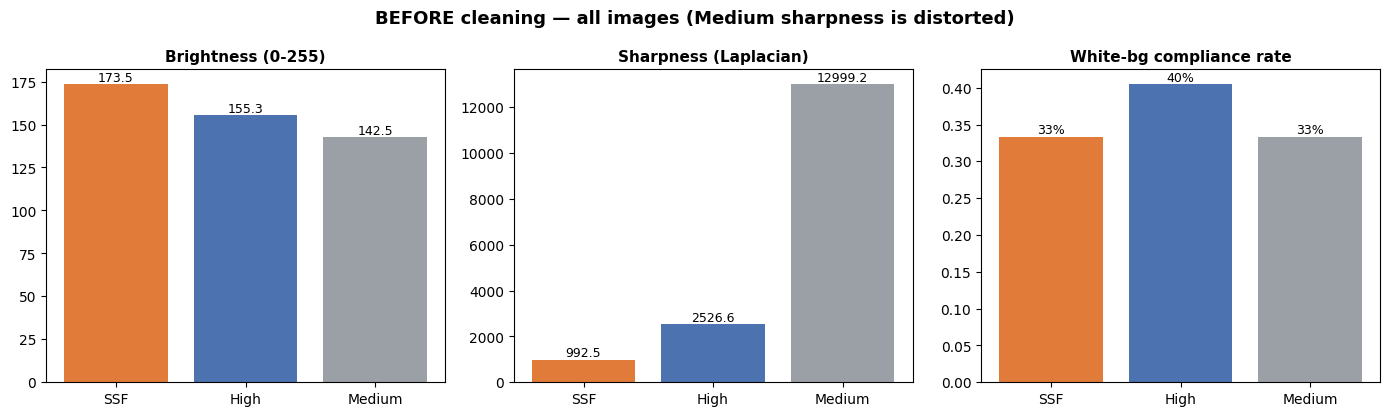

In [18]:
naive = pd.DataFrame({
    'SSF':    ssf[HEADLINE].mean(),
    'High':   high_comp[HEADLINE].mean(),
    'Medium': med_comp[HEADLINE].mean(),
})
print('STAGE 1 — group means on ALL images (potentially distorted):')
print(naive.round(2), '\n')

plot_headline({'SSF': ssf, 'High': high_comp, 'Medium': med_comp},
              ['#E07B39', '#4C72B0', '#9AA0A6'],
              'BEFORE cleaning — all images (Medium sharpness is distorted)')

In [19]:
# Laplacian sharpness is inflated on very small (low-res) images,
# so a few low-res images can dominate a small group's mean.
print('STAGE 2 — sharpness mean vs median (median resists outliers):')
for name, grp in [('SSF', ssf), ('High', high_comp), ('Medium', med_comp)]:
    s = grp['sharpness_laplacian']
    print(f'  {name:<7} mean={s.mean():>9.1f}  median={s.median():>9.1f}  '
          f'min={s.min():>7.1f}  max={s.max():>9.1f}')

print('\nquality_flag breakdown by original tier:')
print(pd.crosstab(df_clean['tier_original'], df_clean['quality_flag']), '\n')

STAGE 2 — sharpness mean vs median (median resists outliers):
  SSF     mean=    992.5  median=   1062.3  min=  421.9  max=   1375.6
  High    mean=   2526.6  median=    708.7  min=   26.1  max=  25452.8
  Medium  mean=  12999.2  median=  11754.1  min=  394.3  max=  26810.6

quality_flag breakdown by original tier:
quality_flag   banner_screenshot  low_resolution  ok
tier_original                                       
high                           6              12  24
medium                         0               5   1
sponsor                        0               0   6 



In [20]:
''' Image resolution versus tier performance:
Does the resolution associate with the performance tier?

Added oer professor feedback
- instead of exluding low-resolution images from the dataset
  treating resolution as a study variable will help determine if the image quality is a predictor of the listing performance
'''

df_clean['resolution_tier'] = 'standard'
los_res = (df_clean['width_px'] < 400) & (df_clean['height_px'])
df_clean.loc[los_res, 'resolution_tier'] = 'low'
print('Resolution vs perfomance tier breakdown:')
print(df_clean.groupby(['performance_tier','resolution_tier']).size().unstack(fill_value=0))

Resolution vs perfomance tier breakdown:
resolution_tier   low  standard
performance_tier               
high               14        28
medium              5         1
sponsor             0         6


STAGE 3 — clean images only (SSF: 6, High: 42):
                     SSF_mean  High_mean  SSF_median  High_median
brightness_mean        173.46     155.35      171.68       157.06
sharpness_laplacian    992.48    2526.62     1062.34       708.73
white_bg_compliance      0.33       0.40        0.00         0.00


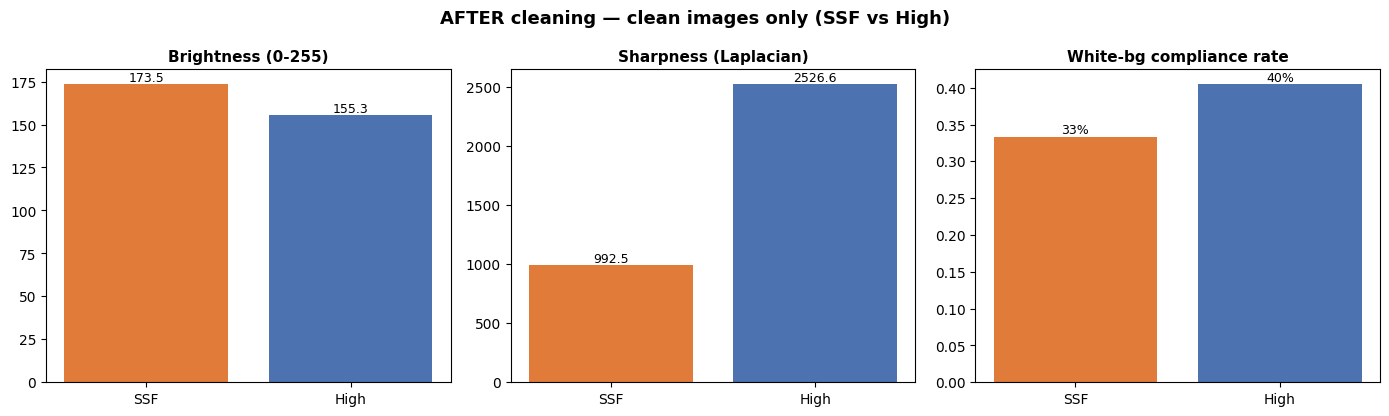

In [21]:
# Keep quality_flag == 'ok' to drop low-res and banner images that
# distort brightness/sharpness. Medium keeps only 1 clean image,
# so the comparison focuses on SSF vs High competitors.
ssf_ok  = ssf.copy()
high_ok = high_comp.copy()

clean_summary = pd.DataFrame({
    'SSF_mean':    ssf_ok[HEADLINE].mean(),
    'High_mean':   high_ok[HEADLINE].mean(),
    'SSF_median':  ssf_ok[HEADLINE].median(),
    'High_median': high_ok[HEADLINE].median(),
})
print(f'STAGE 3 — clean images only (SSF: {len(ssf_ok)}, High: {len(high_ok)}):')
print(clean_summary.round(2))

plot_headline({'SSF': ssf_ok, 'High': high_ok},
              ['#E07B39', '#4C72B0'],
              'AFTER cleaning — clean images only (SSF vs High)')

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# --- Work on clean images only ---
clean = df_clean.copy()

# Candidate visual features (same family as the template's CV_FEATURES)
FEATURES = [
    'brightness_mean', 'contrast_std', 'sharpness_laplacian',
    'white_bg_pct', 'white_bg_compliance', 'product_dominance_score',
    'text_density_pct', 'clutter_score', 'color_warmth',
    'saturation_mean', 'symmetry_score', 'ocr_keyword_count',
]

# Binary target: 1 = high performer, 0 = everything else.
# (medium/low have too few clean images to model separately.)
clean['is_high'] = (clean['performance_tier'] == 'high').astype(int)

In [23]:
# METHOD A — point-biserial correlation between each feature and
# is_high. |r| ranks how strongly a feature separates high vs rest.
corr_rank = (clean[FEATURES]
             .corrwith(clean['is_high'])
             .abs()
             .sort_values(ascending=False))
print('=== Feature ranking by |correlation| with high-performance ===')
print(corr_rank.round(3).to_string(), '\n')

=== Feature ranking by |correlation| with high-performance ===
contrast_std               0.311
sharpness_laplacian        0.297
text_density_pct           0.207
ocr_keyword_count          0.190
white_bg_pct               0.119
saturation_mean            0.077
white_bg_compliance        0.061
product_dominance_score    0.056
clutter_score              0.055
brightness_mean            0.026
color_warmth               0.009
symmetry_score             0.006 



In [24]:
# METHOD B — Random Forest importance (cross-check).
# Small sample, so treat this as corroboration, not ground truth.
X = StandardScaler().fit_transform(clean[FEATURES].fillna(clean[FEATURES].median()))
y = clean['is_high'].values
rf = RandomForestClassifier(n_estimators=300, random_state=42,
                            class_weight='balanced')
rf.fit(X, y)
rf_rank = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('=== Random Forest feature importance (cross-check) ===')
print(rf_rank.round(3).to_string(), '\n')


=== Random Forest feature importance (cross-check) ===
saturation_mean            0.169
contrast_std               0.141
white_bg_pct               0.109
text_density_pct           0.090
sharpness_laplacian        0.088
symmetry_score             0.081
color_warmth               0.074
clutter_score              0.070
brightness_mean            0.067
product_dominance_score    0.067
ocr_keyword_count          0.038
white_bg_compliance        0.006 



Top 3 features separating high performers: ['contrast_std', 'sharpness_laplacian', 'text_density_pct'] 



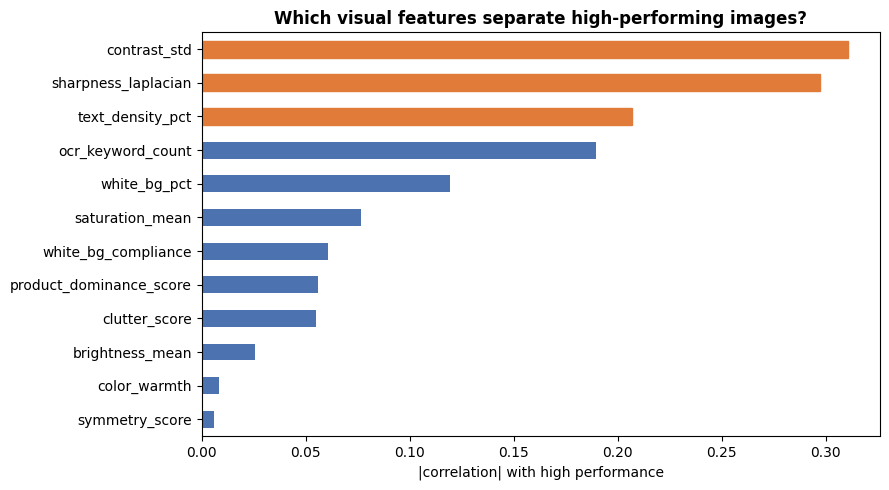

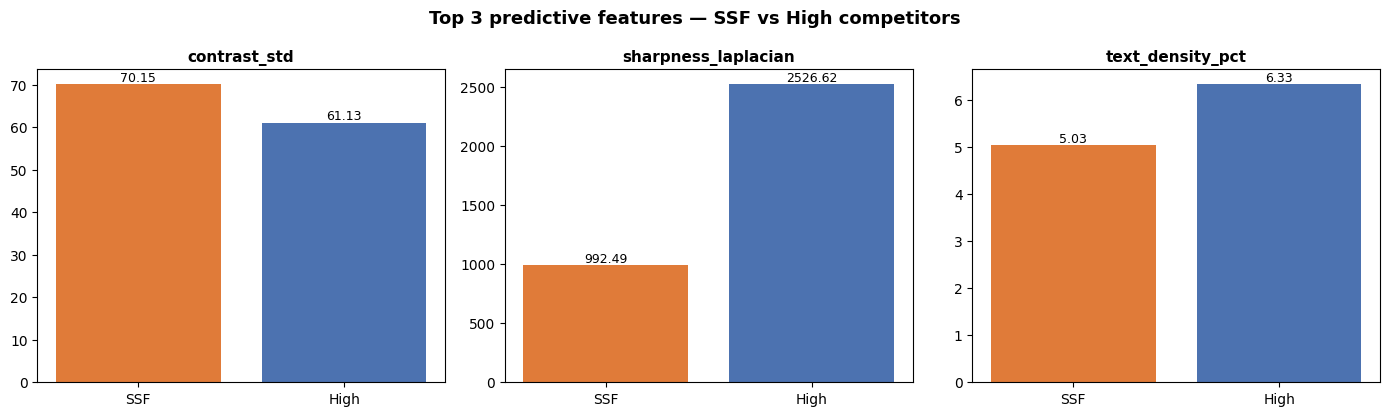

In [25]:
top3 = corr_rank.head(3).index.tolist()
print('Top 3 features separating high performers:', top3, '\n')

# CHART 1 — feature importance bar chart (correlation ranking)
fig, ax = plt.subplots(figsize=(9, 5))
corr_rank.sort_values().plot(kind='barh', color='#4C72B0', ax=ax)
# highlight the top 3 in orange
for i, feat in enumerate(corr_rank.sort_values().index):
    if feat in top3:
        ax.patches[i].set_color('#E07B39')
ax.set_title('Which visual features separate high-performing images?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('|correlation| with high performance')
plt.tight_layout()
plt.show()

# CHART 2 — top 3 features: SSF vs High competitors
# Shows where SSF sits on each of the most predictive features.
ssf_ok  = clean[clean['tier_original'] == 'sponsor']
high_ok = clean[clean['tier_original'] == 'high']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, feat in zip(axes, top3):
    ssf_val, high_val = ssf_ok[feat].mean(), high_ok[feat].mean()
    bars = ax.bar(['SSF', 'High'], [ssf_val, high_val],
                  color=['#E07B39', '#4C72B0'])
    ax.set_title(feat, fontsize=11, fontweight='bold')
    for bar, val in zip(bars, [ssf_val, high_val]):
        ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.2f}',
                ha='center', va='bottom', fontsize=9)
fig.suptitle('Top 3 predictive features — SSF vs High competitors',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== High-competitor benchmark (target values) ===
  white_bg_compliance        0.40   (better = high)
  white_bg_pct              30.04   (better = high)
  color_warmth              13.68   (better = low)
  text_density_pct           6.33   (better = low)
  brightness_mean          155.35   (better = high)
  sharpness_laplacian     2526.62   (better = high)

=== Per-image diagnostic (FAIL = below competitor benchmark) ===
               image  white_bg_compliance white_bg_compliance_fail  white_bg_pct white_bg_pct_fail  color_warmth color_warmth_fail  text_density_pct text_density_pct_fail  brightness_mean brightness_mean_fail  sharpness_laplacian sharpness_laplacian_fail  num_issues
B07TGDFPBN_img04.jpg                  0.0                     FAIL         28.68              FAIL         36.76              FAIL              7.02                  FAIL           140.60                 FAIL              1160.68                     FAIL           6
B07TGDFPBN_img06.jpg                  0.

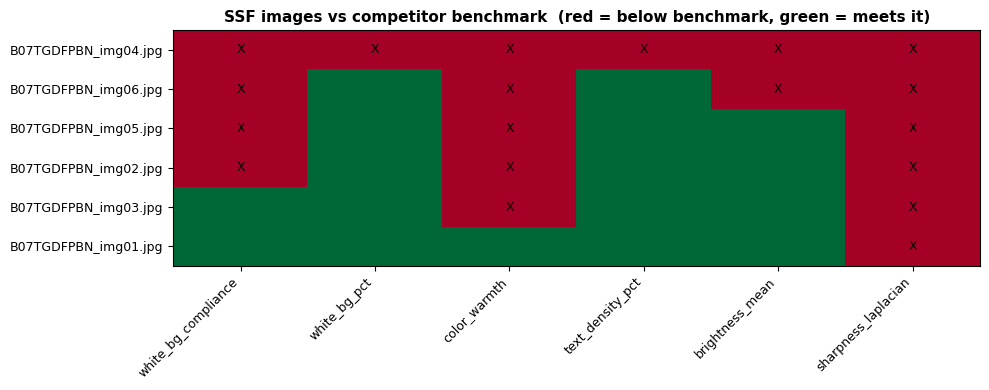

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Work on clean images only (consistent with Tasks 1-2)
clean   = df_clean.copy()
ssf_ok  = clean[clean['tier_original'] == 'sponsor'].copy()
high_ok = clean[clean['tier_original'] == 'high'].copy()


# Define the benchmark and the "good direction" for each feature.
# benchmark = high-competitor mean.
# direction = 'high' means a larger value is better (SSF fails if below);
#             'low'  means a smaller value is better (SSF fails if above).
CHECKS = {
    'white_bg_compliance': 'high',   # want MORE compliant white background
    'white_bg_pct':        'high',   # want MORE white background
    'color_warmth':        'low',    # want LESS warm (competitors are cooler)
    'text_density_pct':    'low',    # want LESS on-image text
    'brightness_mean':     'high',   # want adequate brightness
    'sharpness_laplacian': 'high',   # want sharper images
}

benchmark = {f: high_ok[f].mean() for f in CHECKS}
print('=== High-competitor benchmark (target values) ===')
for f, v in benchmark.items():
    print(f'  {f:<22} {v:>8.2f}   (better = {CHECKS[f]})')


# Build a per-image diagnostic table.
# For each SSF image and each feature, record the value, whether
# it falls short of the benchmark, and by how much (% gap).
records = []
for _, row in ssf_ok.iterrows():
    rec = {'image': row['image_filename']}
    n_fail = 0
    for f, direction in CHECKS.items():
        val, bench = row[f], benchmark[f]
        # a "fail" = on the wrong side of the benchmark
        fail = (val < bench) if direction == 'high' else (val > bench)
        gap_pct = (val - bench) / bench * 100 if bench != 0 else np.nan
        rec[f] = round(val, 2)
        rec[f + '_fail'] = 'FAIL' if fail else 'ok'
        if fail:
            n_fail += 1
    rec['num_issues'] = n_fail
    records.append(rec)

diag = pd.DataFrame(records).sort_values('num_issues', ascending=False)

# Table 1: values with pass/fail per feature
show_cols = ['image'] + [c for f in CHECKS for c in (f, f + '_fail')] + ['num_issues']
print('\n=== Per-image diagnostic (FAIL = below competitor benchmark) ===')
print(diag[show_cols].to_string(index=False))

# Table 2: plain-language issue list per image (actionable)
DIRECTION_MSG = {
    'white_bg_compliance': 'background not compliant (needs cleaner white bg)',
    'white_bg_pct':        'too little white background',
    'color_warmth':        'colour too warm (shift toward neutral/cool)',
    'text_density_pct':    'too much on-image text (reduce text)',
    'brightness_mean':     'too dark',
    'sharpness_laplacian': 'not sharp enough',
}
print('\n=== Actionable issues per SSF image ===')
for _, row in diag.iterrows():
    issues = [DIRECTION_MSG[f] for f in CHECKS if row[f + '_fail'] == 'FAIL']
    print(f'\n{row["image"]}  ({row["num_issues"]} issue(s)):')
    if issues:
        for msg in issues:
            print(f'   - {msg}')
    else:
        print('   - meets all benchmarks')


# CHART — heatmap-style view: which image fails which feature
# (red = fails benchmark, green = meets it)
fail_matrix = diag.set_index('image')[[f + '_fail' for f in CHECKS]]
fail_matrix = (fail_matrix == 'FAIL').astype(int)   # 1 = fail, 0 = ok
fail_matrix.columns = list(CHECKS.keys())

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(fail_matrix.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(CHECKS)))
ax.set_xticklabels(list(CHECKS.keys()), rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(fail_matrix)))
ax.set_yticklabels(fail_matrix.index, fontsize=9)
ax.set_title('SSF images vs competitor benchmark  '
             '(red = below benchmark, green = meets it)',
             fontsize=11, fontweight='bold')
# annotate cells
for i in range(fail_matrix.shape[0]):
    for j in range(fail_matrix.shape[1]):
        txt = 'X' if fail_matrix.values[i, j] == 1 else ''
        ax.text(j, i, txt, ha='center', va='center', fontsize=9, color='black')
plt.tight_layout()
plt.show()

In [27]:
# ---- Section 5.1: Setup ----
# IMG_SIZE = 224 standardizes every image to 224x224, the common input size for
# ResNet50 / CLIP. Augmented images are written to a subfolder under OUTPUTS_DIR.

IMG_SIZE = 224
AUG_DIR = os.path.join(OUTPUTS_DIR, 'augmented')
os.makedirs(AUG_DIR, exist_ok=True)

print(f'Target image size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Augmented images will be saved to: {AUG_DIR}')

Target image size: 224x224
Augmented images will be saved to: /content/drive/MyDrive/xn-sitstayforever/outputs/augmented


In [28]:
# ---- Section 5.2: Select which images to augment ----
''' Decide who gets augmented and by how much.
1. Exclude sponsor images (held-out evaluation set per instructor feedback).
2. Compare tier counts and treat the smaller tier as the minority.
3. Compute variations dynamically with len()/counts so nothing is hard-coded;
   if the cleaned dataset changes upstream, just re-run this cell.
'''

# training pool = everything except sponsor images
train_pool = df_clean[df_clean['tier_original'] != 'sponsor'].copy()

tier_counts = train_pool['performance_tier'].value_counts()
print('Training pool tier counts (sponsor excluded):')
for tier, count in tier_counts.items():
    print(f'  {tier}: {count}')

# identify majority / minority dynamically
majority_count = tier_counts.max()
minority_tier = tier_counts.idxmin()
minority_count = tier_counts.min()

# variations per minority image needed to roughly match the majority tier
variations_per_image = max(1, round(majority_count / minority_count))

print(f'\nMinority tier: {minority_tier} ({minority_count} images)')
print(f'Majority tier count: {majority_count}')
print(f'Variations to generate per minority image: {variations_per_image}')

Training pool tier counts (sponsor excluded):
  high: 42
  medium: 6

Minority tier: medium (6 images)
Majority tier count: 42
Variations to generate per minority image: 7


In [29]:
# ---- Section 5.3: Define the transforms ----
''' Two transform pipelines:
- base_transform: resize only (standardization applied to every image)
- augment_transform: mild random changes to generate new minority-tier variations.
  Keeping the changes random and mild means each pass produces a slightly
  different image without distorting it beyond recognition.
'''

# standardization only (resize to square, no distortion)
base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

# augmentation (for generating new minority-tier variations)
augment_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),  # slight crop + resize
    transforms.RandomHorizontalFlip(p=0.5),                     # 50% chance mirror
    transforms.RandomRotation(15),                              # up to +/-15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),       # mild lighting changes
])

In [30]:
# ---- Section 5.4: Generate & save images + labels ----
''' A) Standardize every training image and save it.
    B) For the minority tier, generate variations_per_image augmented copies each.
    C) Record a labels row for every saved image and write a labels CSV that
       Notebook 2 can load directly. '''

labels_records = []

def save_image(img, filename, tier, is_augmented):
    """Save one PIL image to AUG_DIR and record its label."""
    out_path = os.path.join(AUG_DIR, filename)
    img.convert('RGB').save(out_path)
    labels_records.append({
        'filename': filename,
        'performance_tier': tier,
        'is_augmented': is_augmented,
    })

# --- A) Standardize every training image (originals) ---
for _, row in train_pool.iterrows():
    fname = row['image_filename']
    tier = row['performance_tier']
    src_path = image_paths.get(fname, os.path.join(IMAGE_DIR, fname))
    try:
        img = Image.open(src_path).convert('RGB')
    except Exception as e:
        print(f'Skip (cannot open) {fname}: {e}')
        continue
    standardized = base_transform(img)
    save_image(standardized, fname, tier, is_augmented=False)

# --- B) Augment the minority tier only ---
minority_rows = train_pool[train_pool['performance_tier'] == minority_tier]
for _, row in minority_rows.iterrows():
    fname = row['image_filename']
    tier = row['performance_tier']
    src_path = image_paths.get(fname, os.path.join(IMAGE_DIR, fname))
    try:
        img = Image.open(src_path).convert('RGB')
    except Exception as e:
        print(f'Skip (cannot open) {fname}: {e}')
        continue
    stem, ext = os.path.splitext(fname)
    for i in range(variations_per_image):
        aug_img = augment_transform(img)
        aug_name = f'{stem}_aug{i}{ext}'
        save_image(aug_img, aug_name, tier, is_augmented=True)

# --- C) Save the labels file ---
labels_df = pd.DataFrame(labels_records)
labels_path = os.path.join(OUTPUTS_DIR, 'augmented_labels.csv')
labels_df.to_csv(labels_path, index=False)

print(f'Total images written: {len(labels_df)}')
print(f'Labels file saved to: {labels_path}')

Total images written: 90
Labels file saved to: /content/drive/MyDrive/xn-sitstayforever/outputs/augmented_labels.csv


=== BEFORE augmentation (training pool) ===
  high: 42
  medium: 6

=== AFTER augmentation ===
  medium: 48
  high: 42

Total before: 48  ->  Total after: 90


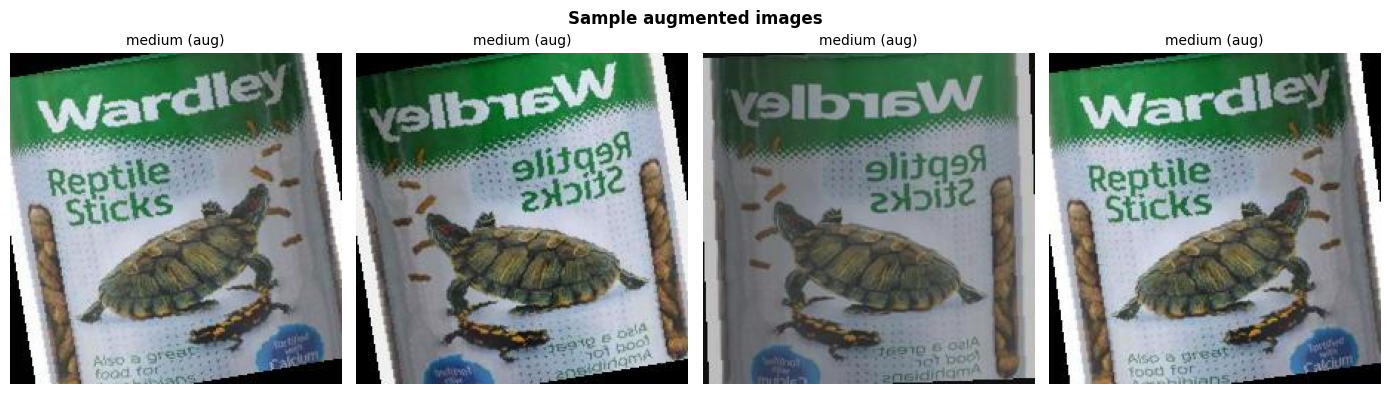

In [31]:
# ---- Section 5.5: Verify (before/after counts + preview) ----
''' Confirm the minority tier was balanced up, and preview a few augmented images. '''

print('=== BEFORE augmentation (training pool) ===')
for tier, count in tier_counts.items():
    print(f'  {tier}: {count}')

print('\n=== AFTER augmentation ===')
after_counts = labels_df['performance_tier'].value_counts()
for tier, count in after_counts.items():
    print(f'  {tier}: {count}')

print(f'\nTotal before: {len(train_pool)}  ->  Total after: {len(labels_df)}')

# preview a few augmented images
aug_samples = labels_df[labels_df['is_augmented']].head(4)
if len(aug_samples) > 0:
    fig, axes = plt.subplots(1, len(aug_samples), figsize=(14, 4))
    if len(aug_samples) == 1:
        axes = [axes]
    for ax, (_, r) in zip(axes, aug_samples.iterrows()):
        img = Image.open(os.path.join(AUG_DIR, r['filename']))
        ax.imshow(img)
        ax.set_title(f"{r['performance_tier']} (aug)", fontsize=10)
        ax.axis('off')
    fig.suptitle('Sample augmented images', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

#Section 6: CLIP Scoring

In [32]:
'''
CLIP - Contrsative Language-Image Pre-Training

- used to measure how well each product image communicates a text concept
- using cosine similarity to compute between each image and targeted keyword queries

Higher Score means better match, and stronger visual-semantic alignment between the image and search term

- No model training needed
- Zero-shot

Model: ViT-B-16 pretrained on DataComp-1B(datacomp_xl_s13_b90k)
References: https://pypi.org/project/open-clip-torch/
- Usage
- Generating text with CoCa


Using update model because it can be ran at 224px, which matches
the pipeline preprocessing setup.
- DataComp-1B has a high percetange of accuracy at 73.5%, and is one of the top
performing models as recognized in the Documentation

Clip will be the primary tool for this analysis given the SSF dataset is limited to 54-images

'''


model, _, preprocessing = open_clip.create_model_and_transforms(
    model_name='ViT-B-32',
    pretrained='datacomp_xl_s13b_b90k',
)

tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Use GPU is present, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print('/n/nModel configuration and loading successful!')
print('=' * 50)
print(f'CLIP model: ViT-B-32 (Pretrained on DataComp-1B(datacomp_xl_s13_b90k))')
print(f'Device: {device}')

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/n/nModel configuration and loading successful!
CLIP model: ViT-B-32 (Pretrained on DataComp-1B(datacomp_xl_s13_b90k))
Device: cpu


In [33]:
# ----- Inspecting and define text queries the dataset from the SSF dataset: keywords sheet,  ------
'''

The goal is to inspect all 54 images in a single pass against the 20 targeted search queries.
Running this in one pass will be intense but ensure consistency across similarity scores. (we have enabled the model state above and will have query embeddings for final computation)
This will be pulled from df_keywords (the keywords_data sheet)

Then resulrs will be split in two outputs to handle the train and eval sets

- clip_train.csv: for feature pattern analysis (high + medium tiers)
- clip_eval.csv: for final benchmarking and recommendations, sponsor tier ( this information can be shared with vendor for metrics, reasoning, and analysis)

'''
# using the df_clean to get df_keywords called above for keyword set only

print('Columns:', df_keywords.columns.tolist())
print('~' * 50)
print(f'Total keywords counted: {len(df_keywords)}')
print('~' * 50)
# print the first 10 row
print(df_keywords.head(10).to_string(index=False))

Columns: ['keyword_id', 'keyword', 'category', 'intent_level', 'keyword_type', 'search_volume_estimate', 'competition_level', 'source', 'relevant_cv_feature', 'relevant_image_element', 'use_for', 'notes']
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Total keywords counted: 146
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
 keyword_id                        keyword      category intent_level keyword_type search_volume_estimate competition_level             source  relevant_cv_feature  relevant_image_element               use_for                                           notes
          1          waterless dog shampoo core_category         high      primary                   high              high competitor_listing  sharpness_laplacian    product shot clarity Amazon title, backend           Main category term — high competition
          2                dry dog shampoo core_category         high      primary                   high              high       sponsor_docs      b

In [34]:
# ----- Selecting 20 queries from the keywords_dataset ---------
'''
The goal here is to select the top 20 based on intent levels across the catergories.
- Will utilize the 'High Search Volume" category because it shows direct intent

- other columns that have important use:
  - relevant_cv_feature: can compare the CLIP score against a CV feature from the EDA
  - relevant_image_element: identifies the element that drives the keyword
  - use_for: where the SSF should apply the keyword
'''

# creating a sort of the search_volume_estimate column, to help understand most relevant terms
df_keywords_sorted = df_keywords.sort_values(by='search_volume_estimate', ascending=False)

# sample top 2 per category for broad coverage, using pandas method chaining
queries_df = (
    df_keywords_sorted
    .groupby('category')
    .head(2)
    .drop_duplicates(subset='keyword')
    .head(20)
    [['keyword', 'category', 'intent_level',
      'search_volume_estimate', 'relevant_cv_feature',
      'relevant_image_element', 'use_for']]
    .reset_index(drop=True)
)

# Extract keyword list for CLIP tokenizer
text_queries = queries_df['keyword'].tolist()

# Print the selected keywords

print('Selected Keywords:')
print('=' * 50)
print(queries_df.to_string(index=False))

Selected Keywords:
                              keyword            category intent_level search_volume_estimate     relevant_cv_feature  relevant_image_element               use_for
         labrador odor control powder      breed_specific       medium                 medium         brightness_mean         background_type        Amazon bullets
   what to use instead of dog shampoo           long_tail         high                 medium     has_lifestyle_image               has_human             blog, FAQ
           baking soda dog deodorizer  ingredient_formula       medium                 medium          dominant_color            color_scheme    Amazon bullets, A+
                   instant relief dog           emotional         high                 medium               has_human                 has_pet bullets, Amazon title
               kaolin clay dog powder  ingredient_formula       medium                 medium         brightness_mean         background_type    Amazon bullets, 

In [41]:
# ----- Compute CLIP Similarity Scores ------
'''

- For each of the 54 images, a cosine similarity score will be compute against the 20 text queries using the ViT-B-16 Model

- we decided to incoporate torch.no_grad() to ensure no gradients are computed during this process
  - it also well help with speed and memory efficiency

  will combine both text and image embedding to enable zero-shot classification

  references:
  https://intfiction.org/t/i6-encode-text-opcode-whats-it-for/48189
  https://github.com/openai/CLIP
'''

# tokenize the 20 text queries
text_tokens = tokenizer(text_queries).to(device)

# store the encoded queries in empty list
results = []

with torch.no_grad():
  # encode all text quesries into embedding
  text_features = model.encode_text(text_tokens) # converts the natural text into numerical embeddings
  text_features = text_features / text_features.norm(dim=-1, keepdim=True) # normalize the embeddings

  for filename, img in tqdm(images.items(), desc="Scoring images"): # images is being called from intital loading of thr 54 images

    # preprocess tensors and encode
    img_tensor = preprocessing(img).unsqueeze(0).to(device)
    image_features = model.encode_image(img_tensor)
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    # applying cosine similarity; squeeze it used to flatten unnecessary layers
    cosine_similarities = (image_features @ text_features.T).squeeze(0).cpu().numpy() # using matrix multiplication, transpose the matrix then flatten to convert to numpy array.

    # build each row, where its one query per
    row = {'image_filename': filename}
    for i, query in enumerate(text_queries):
      row[query] = round(float(cosine_similarities[i]),4)

    # get the mean for all queries
    mean_score = round(float(cosine_similarities.mean()), 4)
    row['mean_score'] = mean_score
    results.append(row)

# build final scores DataFrame
clip_scores_df = pd.DataFrame(results)

print(f'Scored: {len(clip_scores_df)} images')
print('=' * 50)
print(f'Columns: {len(clip_scores_df.columns)} ({len(text_queries)} queries + filename + mean)')
print('=' * 50)
print(clip_scores_df[['image_filename', 'mean_score']].sort_values('mean_score', ascending=False).head(10).to_string(index=False))


Scoring images: 100%|██████████| 63/63 [00:19<00:00,  3.27it/s]

Scored: 63 images
Columns: 22 (20 queries + filename + mean)
                   image_filename  mean_score
             B01J8JMFKG_img02.jpg      0.2242
    coat_defense_03_lifestyle.jpg      0.2149
B0CXDZJLVC_coat_defense_img03.jpg      0.2148
  coat_defense_04_amazon_set2.jpg      0.2115
B0CXDZJLVC_coat_defense_img04.jpg      0.2115
             B07TGDFPBN_img03.jpg      0.2112
             B00GZQYLOE_img04.jpg      0.2104
             B00GZQYLOE_img01.jpg      0.2085
             B07TGDFPBN_img01.jpg      0.2073
             B00GZQYLOE_img03.jpg      0.2070


In [68]:
# ---- Merge CLIP scores with image metadata

# checking to ensure iwe have the right image column
print(df_clean.columns)
print('~'*60)
print([c for c in df_clean.columns if 'file' in c.lower() or 'image' in c.lower()])

# merge the scores and metadata
clip_scores_merged = clip_scores_df.merge(
    df_clean[[
        'image_filename', 'asin', 'brand', 'performance_tier',
        'tier_original', 'quality_flag'
    ]],
    on='image_filename',
    how='inner'
)

print('='*60)
print('Tier distribution in merged scores:')
for tier, count in clip_scores_merged['tier_original'].value_counts().items():
  print(f'  {tier}: {count}')

# Fix: Sum the counts directly from the value_counts() Series
total_sum = clip_scores_merged['tier_original'].value_counts().sum()
print(f'Total merged images: {total_sum}')
print('~' * 60)
print(clip_scores_merged[['image_filename', 'brand', 'tier_original', 'mean_score']].sort_values('mean_score', ascending=False).head(10).to_string(index=False))


Index(['row_id', 'asin', 'brand', 'product_name', 'category',
       'performance_tier', 'known_rating', 'known_reviews', 'known_price_usd',
       'known_bsr_pets', 'image_filename', 'image_index', 'image_type_label',
       'width_px', 'height_px', 'aspect_ratio', 'brightness_mean',
       'brightness_category', 'contrast_std', 'sharpness_laplacian',
       'is_blurry', 'background_type', 'white_bg_pct', 'white_bg_compliance',
       'product_dominance_score', 'text_density_pct', 'clutter_score',
       'color_warmth', 'green_ratio', 'saturation_mean', 'symmetry_score',
       'dominant_color_1', 'dominant_color_1_pct', 'dominant_color_2',
       'dominant_color_2_pct', 'dominant_color_3', 'dominant_color_3_pct',
       'ocr_word_count', 'ocr_keyword_count', 'ocr_keyword_hits', 'ocr_text',
       'data_source', 'amazon_url', 'source_notes', 'quality_flag',
       'tier_original', 'resolution_tier'],
      dtype='object')
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
['